In [129]:
import os
import json
from tqdm.notebook import tqdm

import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 自作ライブラリの読み込み

In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from src.model import ResNet1d, CNN2LSTM
from src.preprocess.emg import EmgEncoder
from src.preprocess.load_data import *

In [4]:
train = sio.loadmat("../data/train.mat")
test = sio.loadmat("../data/test.mat")

train.keys()

dict_keys(['__header__', '__version__', '__globals__', '0001', '0002', '0003', '0004'])

In [84]:
X = {}
y = {}
test_X = {}
users = ["0001", "0002", "0003", "0004"]

x_scaler = {}
y_scaler = {}

def normalize(data, scaler: MinMaxScaler=None):
    """
    データを特徴量ごとに正規化
    
    Args:
        data (numpy.ndarray): 入力データ (num_data, features, len_sequence)
        scaler (sklearn.preprocessing.MinMaxScaler): (Optional) , 正規化
    Returns:
        normalized_data, MinMaxScaler
    """
    length = len(data)
    data = np.concat(data, axis=1).T # (len_sequence*num_data, features)
    
    if scaler is not None:
        data = scaler.transform(data)
    else:
        scaler = MinMaxScaler()
        data = scaler.fit_transform(data)
        
    data = np.array(np.split(data.T, length, axis=1))
    
    return data, scaler

def inverse_nomalize(data, scaler: MinMaxScaler):
    length = len(data)
    data = np.concat(data, axis=1).T
    data = scaler.inverse_transform(data)
    data = np.array(np.split(data.T, length, axis=1))
    return data

def split_for_pred_1point(data, len=990):
    splited_data = []
    for x in data:
        x = np.array(np.split(x[:, :len], 30, axis=1))
        splited_data.append(x)
    splited_data = np.concat(splited_data)
    return splited_data

pred_1point = True

for user in users:
    train_x = train[user][0][0][0]
    train_y = train[user][0][0][1]
    test_x = test[user][0][0][0]
    
    # 特徴量ごとに正規化
    train_x, x_mm = normalize(train_x)
    train_y, y_mm = normalize(train_y)
    test_x, _ = normalize(test_x, x_mm)
    
    # 正規化に用いたスケーラーを保存
    x_scaler[user] = x_mm
    y_scaler[user] = y_mm
    
    if pred_1point:
        X[user] = split_for_pred_1point(train_x)
        y[user] = split_for_pred_1point(train_y, len=30)
        test_X[user] = split_for_pred_1point(test_x)
    else:
        X[user] = train_x
        y[user] = train_y
        test_X[user] = test_x

X[user].shape, test_X[user].shape

((9600, 16, 33), (9600, 16, 33))

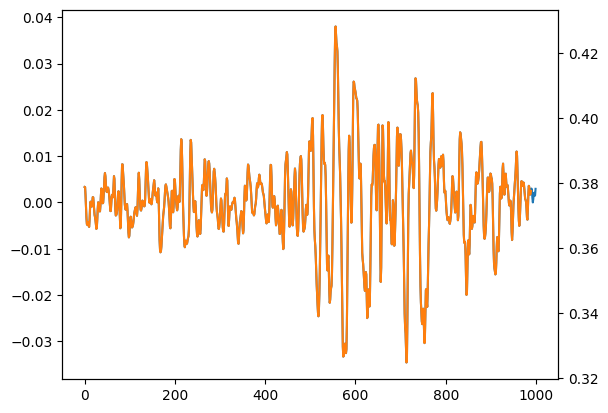

In [89]:
user = "0001"
fig = plt.figure()
ax1 = fig.add_subplot()
ax1.plot(train[user][0][0][0][0, 0, :])
ax2 = ax1.twinx()
ax2.plot(np.concat(X[user][:30, 0, :]), color="C1")

(9600, 16, 33)


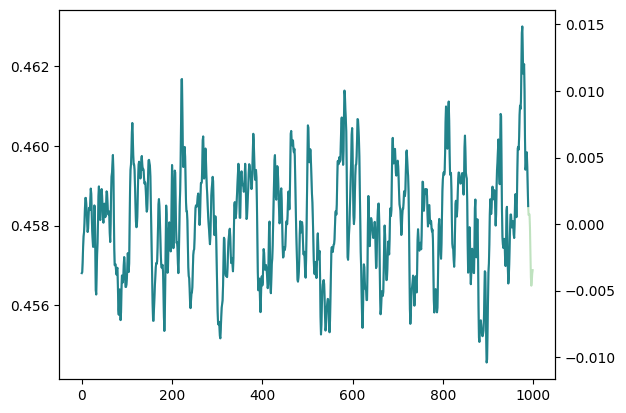

In [69]:
splited_x = []
for x in train_x:
    x = np.array(np.split(x[:, :990], 30, axis=1))
    splited_x.append(x)

splited_x = np.concat(splited_x)
print(splited_x.shape)
fig = plt.figure()
ax1 = fig.add_subplot()
ax1.plot(np.concat([splited_x[i, 0, :] for i in range(30)]))
ax2 = ax1.twinx()
ax2.plot(train[user][0][0][0][0, 0, :], color="C2", alpha=0.3)

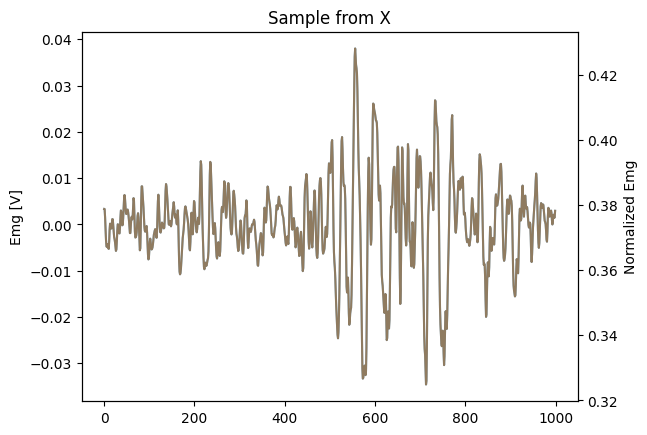

In [6]:
raw_x = train["0001"][0][0][0][0, 0, :]
normalized_x = X["0001"][0, 0, :]

fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.plot(raw_x, color="C0")
ax1.set_ylabel("Emg [V]")
ax2 = ax1.twinx()
ax2.plot(normalized_x, color="C1", alpha=0.5)
ax2.set_ylabel("Normalized Emg")
plt.title("Sample from X")
plt.show()

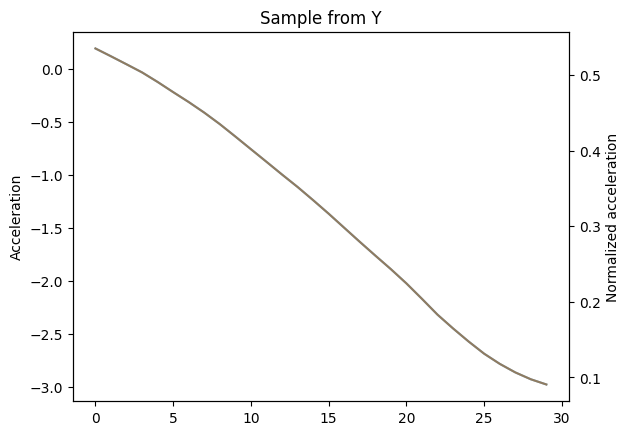

In [7]:
raw_y = train["0001"][0][0][1][0, 0, :]
normalized_y = y["0001"][0, 0, :]

fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.plot(raw_y, color="C0")
ax1.set_ylabel("Acceleration")
ax2 = ax1.twinx()
ax2.plot(normalized_y, color="C1", alpha=0.5)
ax2.set_ylabel("Normalized acceleration")
plt.title("Sample from Y")
plt.show()

# Datasetの作成

In [90]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset, Sampler

In [91]:
class UserDataset(Dataset):
    def __init__(self, X, y=None, user: str="0001", axis=0):
        super().__init__()
        self.X = X
        self.y = y
        self.user = user
        self.axis = axis
    
    def __len__(self):
        return len(self.X[user])
    
    def __getitem__(self, idx):
        # (len_sequence, features) の形で返す
        x = torch.tensor(self.X[self.user][idx, :, :].T, dtype=torch.float32)
        if self.y is None:
            return x
        y = torch.tensor(self.y[self.user][idx, self.axis, :].T, dtype=torch.float32)
        return x, y

train_ds = UserDataset(X, y, user="0001", axis=0)
x_sample, y_sample = next(iter(train_ds))
print(f"Train shapes: X0 = {x_sample.shape}, y0 = {y_sample.shape}")

test_ds = UserDataset(test_X, user="0001", axis=0)
x_sample = next(iter(test_ds))
print(f"Test shape  : X0 = {x_sample.shape}")

print(len(test_ds))

Train shapes: X0 = torch.Size([33, 16]), y0 = torch.Size([1])
Test shape  : X0 = torch.Size([33, 16])
9570


# モデルの作成

In [96]:
class CustomLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, len_sequence: int=1000, output_size: int=30):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.len_sequence= len_sequence
        
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers)
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(hidden_size*len_sequence, output_size)
        
    def forward(self, x):
        h, *_ = self.lstm1(x)
        h = self.flatten(h)
        h = self.linear(h)
        return h

model = CustomLSTM(input_size=16, hidden_size=32, num_layers=1, len_sequence=33, output_size=1)
dummy_input = torch.rand(1, 33, 16)
model(dummy_input)


tensor([[0.0431]], grad_fn=<AddmmBackward0>)

# 学習

In [121]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# モデルの学習に関連するパラメータ
batch_size = 4
epochs = 50
learning_rate = 10e-3
num_workers = 0

# モデルの構造に関連するパラメータ
hidden_size = 64
num_layers = 1
len_sequence = 33 if pred_1point else 1000
output_size = 1 if pred_1point else 30

def train_1epoch(model, loss_fn, optimizer, dataloader):
    total_loss = 0
    for x, y in dataloader:
        optimizer.zero_grad()
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def valid_1epoch(model, loss_fn, dataloader):
    total_loss = 0
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            loss = loss_fn(pred, y).item()
            total_loss += loss
    
    return total_loss / len(dataloader)

def predict(model, dataloader):
    preds = []
    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)
            pred = model(x)
            pred = pred.to("cpu").detach().numpy()
            preds.append(pred)
    
    return np.array(preds)

pred_result = {user: [] for user in users}
for user in users:
    print("="*15)
    print(f" User: {user}")
    
    train_idx, valid_idx = train_test_split(range(len(X[user])), test_size=0.2, shuffle=True, random_state=42)
    valid_true = y[user][valid_idx]
    valid_pred = np.zeros_like(valid_true)
    
    for axis in range(3):
        model = CustomLSTM(input_size=16, hidden_size=hidden_size, num_layers=num_layers, len_sequence=len_sequence, output_size=output_size)
        
        dataset = UserDataset(X, y, user=user, axis=axis)
        test_set = UserDataset(X, user=user, axis=axis)
        train_set = Subset(dataset, train_idx)
        valid_set = Subset(dataset, valid_idx)
        train_loader = DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers
        )
        valid_loader = DataLoader(
            valid_set,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )
        test_loader = DataLoader(
            test_set,
            batch_size=1,
            shuffle=False,
            num_workers=num_workers
        )
        
        history = {"train-loss": [], "valid-loss": []}
        best_loss = 10e9
        best_epoch = 0
        
        loss_fn = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        model.to(device)
        for epoch in tqdm(range(epochs)):
            model.train()
            train_loss = train_1epoch(model, loss_fn, optimizer, train_loader)
            model.eval()
            valid_loss = valid_1epoch(model, loss_fn, valid_loader)
            # print(f"[Epoch {epoch}] train-loss: {train_loss:.5f} valid-loss {valid_loss:.5f}")
            
            history["train-loss"].append(train_loss)
            history["valid-loss"].append(valid_loss)
            
            if valid_loss < best_loss:
                best_loss = valid_loss
                best_epoch = epoch
                best_model = model
        print(f"Best epoch: {best_epoch}, Best Score: {best_loss:.5f}")
        pred = predict(model, test_loader)
        pred_result[user].append(pred)

        valid_x = X[user][valid_idx]
        model.to("cpu")
        valid_pred[:, axis, :] = model(torch.tensor(valid_x.transpose(0, 2, 1), dtype=torch.float32)).detach().numpy()

    valid_pred = inverse_nomalize(valid_pred, y_scaler[user])
    trial_loss = np.sqrt(((valid_true-valid_pred)**2).sum(axis=1).mean())
    print("Trial Loss", trial_loss)


 User: 0001


  0%|          | 0/50 [00:00<?, ?it/s]

Best epoch: 49, Best Score: 0.08487


  0%|          | 0/50 [00:00<?, ?it/s]

Best epoch: 44, Best Score: 0.05121


...

Best epoch: 43, Best Score: 0.09549


  0%|          | 0/50 [00:00<?, ?it/s]

Best epoch: 47, Best Score: 0.03316


  0%|          | 0/50 [00:00<?, ?it/s]

Best epoch: 48, Best Score: 0.03586
Trial Loss 0.944097624081007


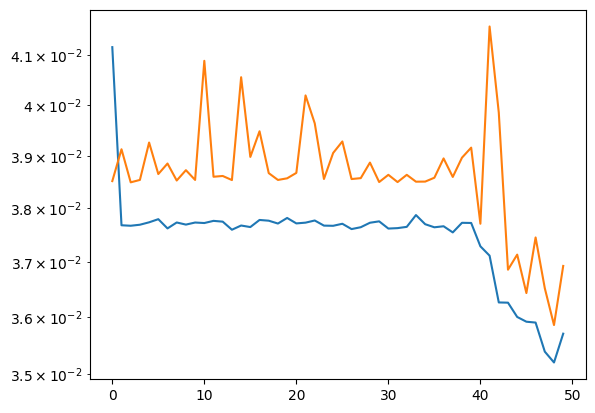

In [124]:
plt.plot(history["train-loss"])
plt.plot(history["valid-loss"])
# plt.ylim([0.01, 0.1])
plt.yscale("log")

# 予測結果の可視化

MAE 0.26818572059989326
MSE 0.1017919322365089
R2  -3662.725070981544


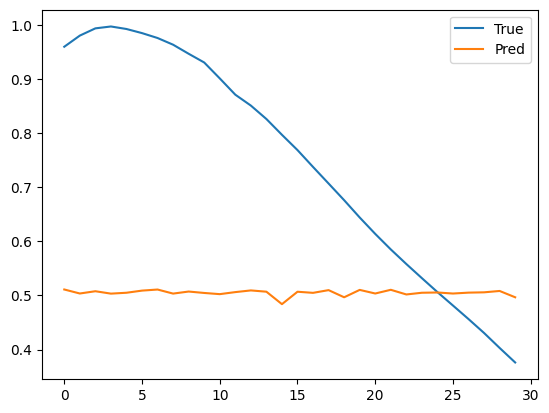

In [133]:
model.to("cpu")
if pred_1point:
    sample_x = X[user][30:60, :, :]
    sample_x = torch.tensor(sample_x.transpose(0, 2, 1), dtype=torch.float32)
    sample_pred = model(sample_x).detach().numpy()
    sample_y = y[user][30:60, axis, :]
    plt.plot(sample_y, label="True")
    plt.plot(sample_pred, label="Pred")
    print("MAE", mean_absolute_error(sample_pred, sample_y))
    print("MSE", mean_squared_error(sample_pred, sample_y))
    print("R2 ", r2_score(sample_pred, sample_y))
else:
    valid_true = y[user][valid_idx]
    valid_pred = np.zeros_like(valid_true)
    valid_x = X[user][valid_idx]
    valid_x = torch.tensor(valid_x.transpose(0, 2, 1), dtype=torch.float32)
    valid_true[:, axis, :] = model(valid_x).detach().numpy()
    plt.plot(valid_true[0, axis, :], label="True")
    plt.plot(valid_pred[0, axis, :], label="Pred")
plt.legend()
plt.show()

# 提出

In [24]:
with open("../data/sample_submit.json") as r:
    sample_submit = json.load(r)

sample_submit.keys()

dict_keys(['sub1', 'sub2', 'sub3', 'sub4'])

In [14]:
for i, user in enumerate(users):
    sub_dict = {}
    pred = np.array(pred_result[user])
    pred = pred[:, :, 0, :]
    pred = pred.transpose(1, 0, 2)
    pred = inverse_nomalize(pred, scaler=y_scaler[user])
    pred = pred.transpose(0, 2, 1)
    for trial, trial_pred in enumerate(pred):
        if trial_pred.shape != (30, 3):
            print("Error")
        sub_dict[f"trial{trial}"] = trial_pred.tolist()
    sample_submit[f"sub{i+1}"] = sub_dict

In [15]:
with open("../data/submission_lstm_per_user_test2.json", "w") as f:
    json.dump(sample_submit, f)